# Baseline Model and Results for the Decision Model

In this notebook, we implement a convolutional neural network (CNN) to classify each images into one of the following categories: art, faces or animals. 

This model will be used as the decision that will call after the predicted label model

## Table of Contents
1. [Imports and Setup](#imports-and-setup)
2. [Helpers functions](#helpers-functions)
3. [Load data](#load-data)
4. [Baseline model](#baseline-model)
5. [Refined model](#refined-model)
6. [Model Evaluation](#model-evaluation)

### Imports and Setup

In [ ]:
import os
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Input
from tensorflow.keras import optimizers
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from tensorflow.keras.models import Model
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import os
import seaborn as sns
import cv2
import pathlib
import random

2025-04-27 18:23:19.108859: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-04-27 18:23:19.108918: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-04-27 18:23:19.109578: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-27 18:23:19.115014: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
#CHECK GPU
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
#### CONSTANTS ###
train_data_path = "../dataset_train"
test_data_path = "../dataset_test"
weigths_path = "../weights"

### Helpers functions

In [ ]:
### HELPERS FUNCTIONS ###
def load_custom_multiclass_dataset(data_path, batch_size=32, img_size=(200, 200), subset_ratio=1.0):
    """
    Custom dataset loader that works with a directory structure like:
    
    data_path/
        art/
            real/
                image1.jpg
                image2.jpg
                ...
            fake/
                image3.jpg
                image4.jpg
                ...
        animals/
            real/
                ...
            fake/
                ...
        faces/
            real/
                ...
            fake/
                ...
    
    The loader ignores the intermediate real/fake folders and uses the top-level folder
    (art, animals, or faces) as the label. It builds a one-hot encoded multiclass dataset.
    
    Parameters:
        data_path (str): Path to the dataset.
        batch_size (int): Number of images per batch.
        img_size (tuple): Target size for images.
        subset_ratio (float): Fraction of samples to use.
        
    Returns:
        A tf.data.Dataset yielding (image, label) pairs and the list of class names.
    """
    data_path = pathlib.Path(data_path)

    image_extensions = ["*.jpg", "*.jpeg", "*.png"]
    all_files = []
    for ext in image_extensions:
        all_files.extend(list(data_path.glob(f"*/*/{ext}")))
    
    all_files = [fp for fp in all_files if fp.is_file()]
    
    def get_category(file_path):
        rel_parts = file_path.relative_to(data_path).parts
        return rel_parts[0]
    
    categories = sorted(list({get_category(fp) for fp in all_files}))
    print("Detected categories:", categories)
    
    label_to_index = {cat: idx for idx, cat in enumerate(categories)}
    
    samples = []
    for fp in all_files:
        category = get_category(fp)
        label_index = label_to_index[category]
        samples.append((str(fp), label_index))
    
    random.shuffle(samples)
    if subset_ratio < 1.0:
        samples = samples[:int(len(samples) * subset_ratio)]
    
    file_paths, labels = zip(*samples)

    ds = tf.data.Dataset.from_tensor_slices((list(file_paths), list(labels)))
    
    def _load_and_preprocess(path, label):
        image = tf.io.read_file(path)

        image = tf.image.decode_image(image, channels=3, expand_animations=False)
        image = tf.image.resize(image, img_size)
        image = tf.cast(image, tf.float32) / 255.0  
        label = tf.one_hot(label, depth=len(categories))
        return image, label
    
    ds = ds.map(_load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    
    return ds, categories



def scale_images_to_unit_range(dataset):
    """
    Applies scaling to images in the dataset so that their pixel values are in the [0, 1] range.
    
    Parameters:
        dataset (tf.data.Dataset): A TensorFlow dataset where each element is a (image, label) pair.
        
    Returns:
        A new tf.data.Dataset with the images scaled to [0, 1].
    """
    def scaling_fn(image, label):
        image = tf.cast(image, tf.float32) / 255.0
        return image, label

    return dataset.map(scaling_fn)

# VISUALIZE TRAINING DATA
def plot_training_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # accuracy
    ax1.plot(history.history['accuracy'])
    ax1.plot(history.history['val_accuracy'])
    ax1.set_title('Model Accuracy')
    ax1.set_ylabel('Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.legend(['Train', 'Validation'], loc='lower right')

    # loss
    ax2.plot(history.history['loss'])
    ax2.plot(history.history['val_loss'])
    ax2.set_title('Model Loss')
    ax2.set_ylabel('Loss')
    ax2.set_xlabel('Epoch')
    ax2.legend(['Train', 'Validation'], loc='upper right')

    plt.tight_layout()
    plt.show()
    

def get_predictions_and_labels(dataset, model):
    """
    Runs model.predict on the whole dataset, returns:
      y_pred: np.array of predicted class indices
      y_true: np.array of true class indices
    """
    y_true = []
    y_pred = []
    for X_batch, y_batch in dataset:
        preds = model.predict(X_batch, verbose=0)
        y_true.extend(np.argmax(y_batch, axis=1))
        y_pred.extend(np.argmax(preds, axis=1))
    return np.array(y_pred), np.array(y_true)
    
def get_sample_images(dataset, class_names, num_samples=5):
    """
    For a multiclass tf.data.Dataset that yields (image, one_hot_label),
    grab `num_samples` per class for quick visualization.
    """
    sample_images = {i: [] for i in range(len(class_names))}
    class_counts = {i: 0 for i in range(len(class_names))}

    for images, labels in dataset:
        labels = labels.numpy()
        imgs = images.numpy()
        for img, one_hot in zip(imgs, labels):
            cls = int(np.argmax(one_hot))
            if class_counts[cls] < num_samples:
                sample_images[cls].append(img)
                class_counts[cls] += 1
        if all(count >= num_samples for count in class_counts.values()):
            break

    # flatten into lists
    imgs, labs = [], []
    for cls, images in sample_images.items():
        imgs.extend(images)
        labs.extend([cls]*len(images))
    return imgs, labs
    
def plot_saliency_and_gradcam_per_class(model, dataset, class_names, last_conv_layer_name):
    # 1) grab one sample per class
    sample_per_class = {}
    for images, labels in dataset:
        imgs = images.numpy()
        one_hots = labels.numpy()
        for img, oh in zip(imgs, one_hots):
            cls = int(np.argmax(oh))
            if cls not in sample_per_class:
                sample_per_class[cls] = img
            if len(sample_per_class) == len(class_names):
                break
        if len(sample_per_class) == len(class_names):
            break

    n = len(class_names)
    fig, axes = plt.subplots(n, 3, figsize=(15, 5 * n))

    for i, cls in enumerate(range(n)):
        img = sample_per_class[cls]
        img_tensor = tf.convert_to_tensor(img[np.newaxis, ...], dtype=tf.float32)

        # original
        axes[i, 0].imshow(img)
        axes[i, 0].set_title(f"{class_names[cls]} – Original")
        axes[i, 0].axis('off')

        # saliency
        with tf.GradientTape() as tape:
            tape.watch(img_tensor)
            preds = model(img_tensor)[0]
            loss = preds[cls]
        grads = tape.gradient(loss, img_tensor)[0]
        sal = np.max(np.abs(grads), axis=-1)
        sal = (sal - sal.min()) / (sal.max() - sal.min() + 1e-8)
        axes[i, 1].imshow(sal, cmap='jet')
        axes[i, 1].set_title("Saliency Map")
        axes[i, 1].axis('off')

        # grad-cam
        grad_model = tf.keras.models.Model(
            model.inputs,
            [model.get_layer(last_conv_layer_name).output, model.output]
        )
        with tf.GradientTape() as tape:
            conv_outs, preds = grad_model(img_tensor)
            loss = preds[:, cls]
        grads = tape.gradient(loss, conv_outs)[0]        
        conv_outs = conv_outs[0]                         
        pooled_grads = tf.reduce_mean(grads, axis=(0,1)) 

        # weighted sum across channels
        heatmap = tf.tensordot(conv_outs, pooled_grads, axes=([2],[0]))
        heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-6)
        heatmap = heatmap.numpy()

        heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
        heatmap = np.uint8(255 * heatmap)

        axes[i, 2].imshow(img)
        axes[i, 2].imshow(heatmap, cmap='jet', alpha=0.4)
        axes[i, 2].set_title("Grad-CAM")
        axes[i, 2].axis('off')

    plt.tight_layout()
    plt.show()


def plot_images_by_category(dataset, class_names, num_per_class=2):
    """
    Plots a specified number of images from each category in the dataset.
    
    Parameters:
        dataset (tf.data.Dataset): The dataset containing image-label pairs
        class_names (list): List of class names
        num_per_class (int): Number of images to display per class
    """
    fig, axes = plt.subplots(len(class_names), num_per_class, figsize=(num_per_class*4, len(class_names)*4))
    
    images_by_class = {cls: [] for cls in range(len(class_names))}
    unbatched_ds = dataset.unbatch()
    
    for image, label in unbatched_ds:
        label_idx = np.argmax(label.numpy())
        if len(images_by_class[label_idx]) < num_per_class:
            images_by_class[label_idx].append(image.numpy())
        if all(len(imgs) >= num_per_class for imgs in images_by_class.values()):
            break

    for i, class_name in enumerate(class_names):
        for j in range(min(num_per_class, len(images_by_class[i]))):
            if len(class_names) > 1:
                ax = axes[i, j]
            else:
                ax = axes[j]
            
            ax.imshow(images_by_class[i][j])
            ax.set_title(f"{class_name}")
            ax.axis('off')
    
    plt.tight_layout()
    plt.show()

### Load data

In [5]:
batch_size = 32
img_size = (200, 200)

In [6]:
train_dataset, class_names = load_custom_multiclass_dataset(train_data_path, batch_size=batch_size, img_size=img_size, subset_ratio=0.33)
test_dataset, _ = load_custom_multiclass_dataset(test_data_path, batch_size=batch_size, img_size=img_size, subset_ratio=0.33)

print("Class names:", class_names)

Detected categories: ['animals', 'art', 'faces']


2025-04-27 18:30:46.308056: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 20763 MB memory:  -> device: 0, name: NVIDIA L4, pci bus id: 0000:3e:00.0, compute capability: 8.9


Detected categories: ['animals', 'art', 'faces']
Class names: ['animals', 'art', 'faces']


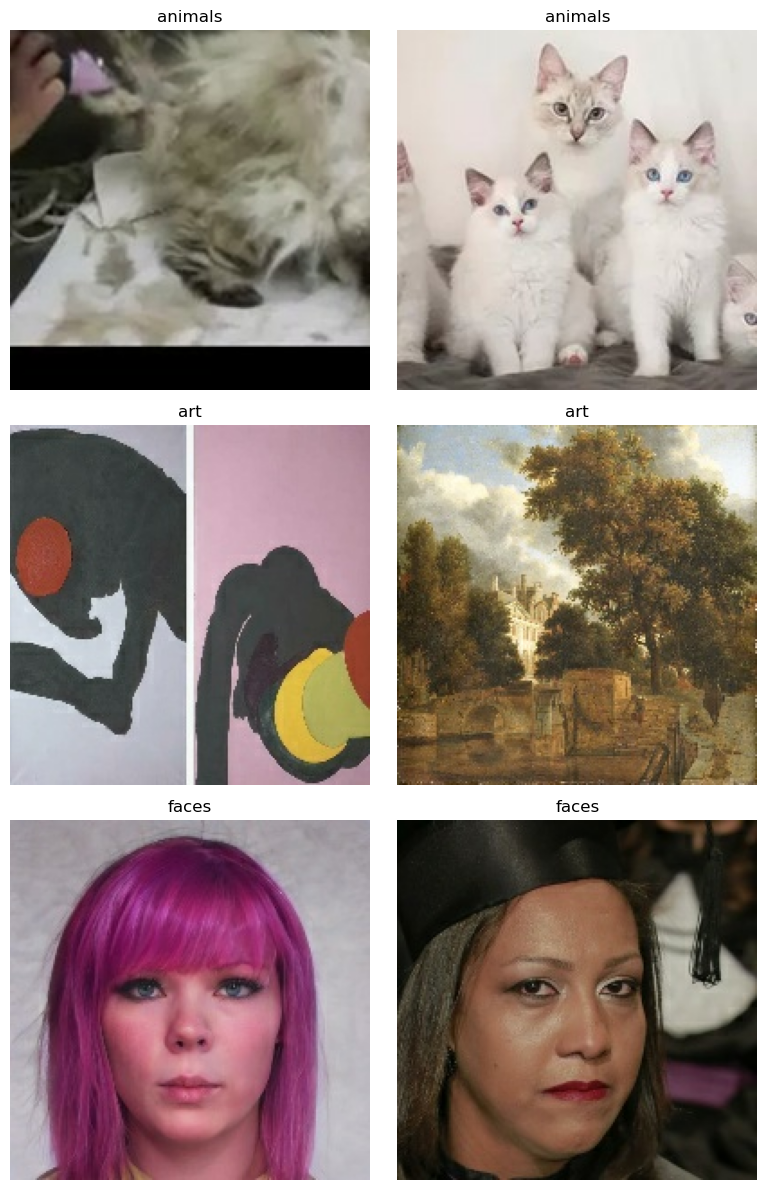

In [26]:
plot_images_by_category(train_dataset, class_names, num_per_class=2)

### Define model

In [ ]:
input_shape = (200, 200, 3)
num_classes = len(class_names)

inputs = Input(shape=input_shape)

# 1st conv
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
x = layers.BatchNormalization()(x)
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2))(x)
x = layers.Dropout(0.25)(x)

# 2nd conv
x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2))(x)
x = layers.Dropout(0.25)(x)


# flatten
x = layers.Flatten()(x)

# ffnn
x = layers.Dense(512, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(num_classes, activation='softmax')(x)

model = Model(inputs=inputs, outputs=outputs)

model.summary()


Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 200, 200, 3)]     0         
                                                                 
 conv2d (Conv2D)             (None, 200, 200, 32)      896       
                                                                 
 batch_normalization (Batch  (None, 200, 200, 32)      128       
 Normalization)                                                  
                                                                 
 conv2d_1 (Conv2D)           (None, 200, 200, 32)      9248      
                                                                 
 batch_normalization_1 (Bat  (None, 200, 200, 32)      128       
 chNormalization)                                                
                                                                 
 max_pooling2d (MaxPooling2  (None, 100, 100, 32)      0     

### Training model

In [9]:
model.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

weights_path = "../weights"
os.makedirs(weights_path, exist_ok=True)

checkpoint = ModelCheckpoint(
    os.path.join(weights_path, 'decision_model.h5'),
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

In [10]:
# training
history = None
if os.path.exists(f"{weigths_path}/decision_model.h5"):
    print("Loading existing model weights...")
    model.load_weights(f"{weigths_path}/decision_model.h5")
    print("Model loaded")
else:
    history = model.fit(
        train_dataset,
        validation_data=test_dataset,
        epochs=10,
        callbacks=[checkpoint, early_stopping, reduce_lr]
    )
    model.save(os.path.join(weights_path, 'decision_model.h5'))
    print("Model saved.")


Epoch 1/10


2025-04-27 18:37:45.792656: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inmodel/dropout/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
2025-04-27 18:37:46.044119: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8907
2025-04-27 18:37:47.997670: I external/local_xla/xla/service/service.cc:168] XLA service 0x1502249dfc40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-04-27 18:37:47.997711: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA L4, Compute Capability 8.9
2025-04-27 18:37:48.002709: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1745793468.083050   29278 device_compiler.h:186] Compiled cluster using XLA!  This line is lo

3118/3118 [==============================] - ETA: 0s - loss: 0.1683 - accuracy: 0.9392
Epoch 1: val_accuracy improved from -inf to 0.85664, saving model to ../weights/decision_model.h5


/shared/courseSharedFolders/142601outer/142601/cs109b/lib/python3.11/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


3118/3118 [==============================] - 380s 118ms/step - loss: 0.1683 - accuracy: 0.9392 - val_loss: 0.4188 - val_accuracy: 0.8566 - lr: 0.0010
Epoch 2/10
3118/3118 [==============================] - ETA: 0s - loss: 0.0655 - accuracy: 0.9775
Epoch 2: val_accuracy improved from 0.85664 to 0.98481, saving model to ../weights/decision_model.h5
3118/3118 [==============================] - 360s 116ms/step - loss: 0.0655 - accuracy: 0.9775 - val_loss: 0.0435 - val_accuracy: 0.9848 - lr: 0.0010
Epoch 3/10
3118/3118 [==============================] - ETA: 0s - loss: 0.0325 - accuracy: 0.9893
Epoch 3: val_accuracy improved from 0.98481 to 0.99435, saving model to ../weights/decision_model.h5
3118/3118 [==============================] - 360s 115ms/step - loss: 0.0325 - accuracy: 0.9893 - val_loss: 0.0185 - val_accuracy: 0.9943 - lr: 0.0010
Epoch 4/10
3118/3118 [==============================] - ETA: 0s - loss: 0.0233 - accuracy: 0.9921
Epoch 4: val_accuracy did not improve from 0.99435
311

### Model evaluation

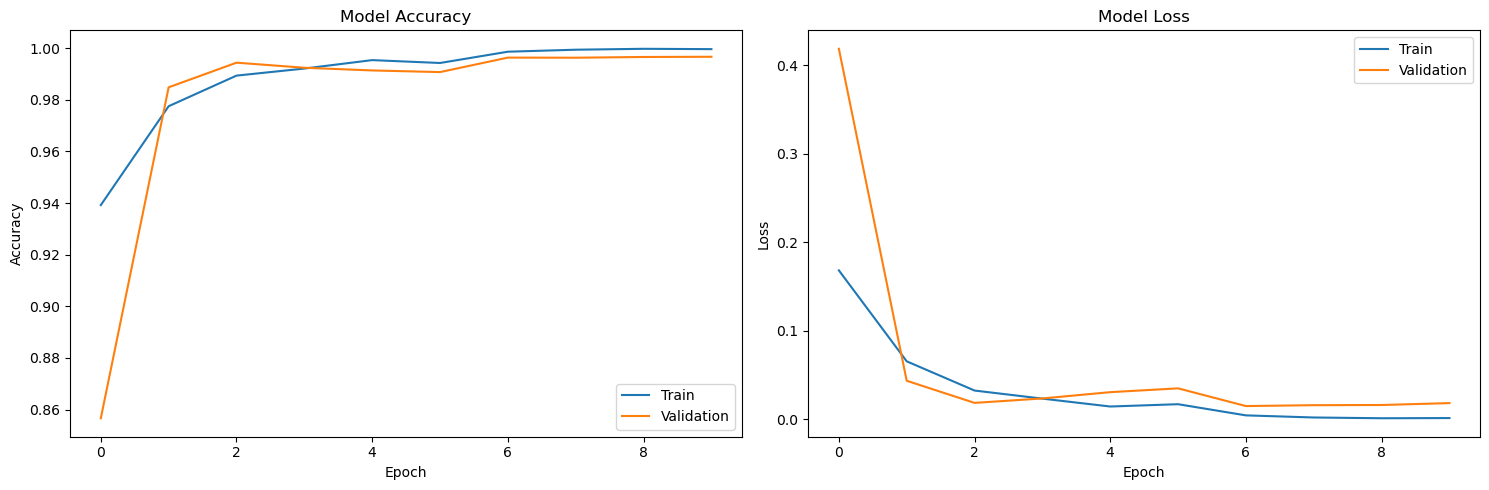

In [11]:
# training history
if history:
    plot_training_history(history)
else:
    # show the image saved in memory
    history_image_path = "../images/decision_model_history.png"

    # show image
    plt.figure(figsize=(14, 8))
    img = plt.imread(history_image_path)
    plt.imshow(img)
    plt.axis('off')
    plt.show()

In [12]:
# model evaluation
evaluation = model.evaluate(test_dataset)
print(f"Test loss: {evaluation[0]:.4f}")
print(f"Test accuracy: {evaluation[1]:.4f}")

780/780 [==============================] - 18s 23ms/step - loss: 0.0183 - accuracy: 0.9966
Test loss: 0.0183
Test accuracy: 0.9966


#### Saliency Map and Grad-CAM heatmap

Last convolutional layer name: conv2d_3


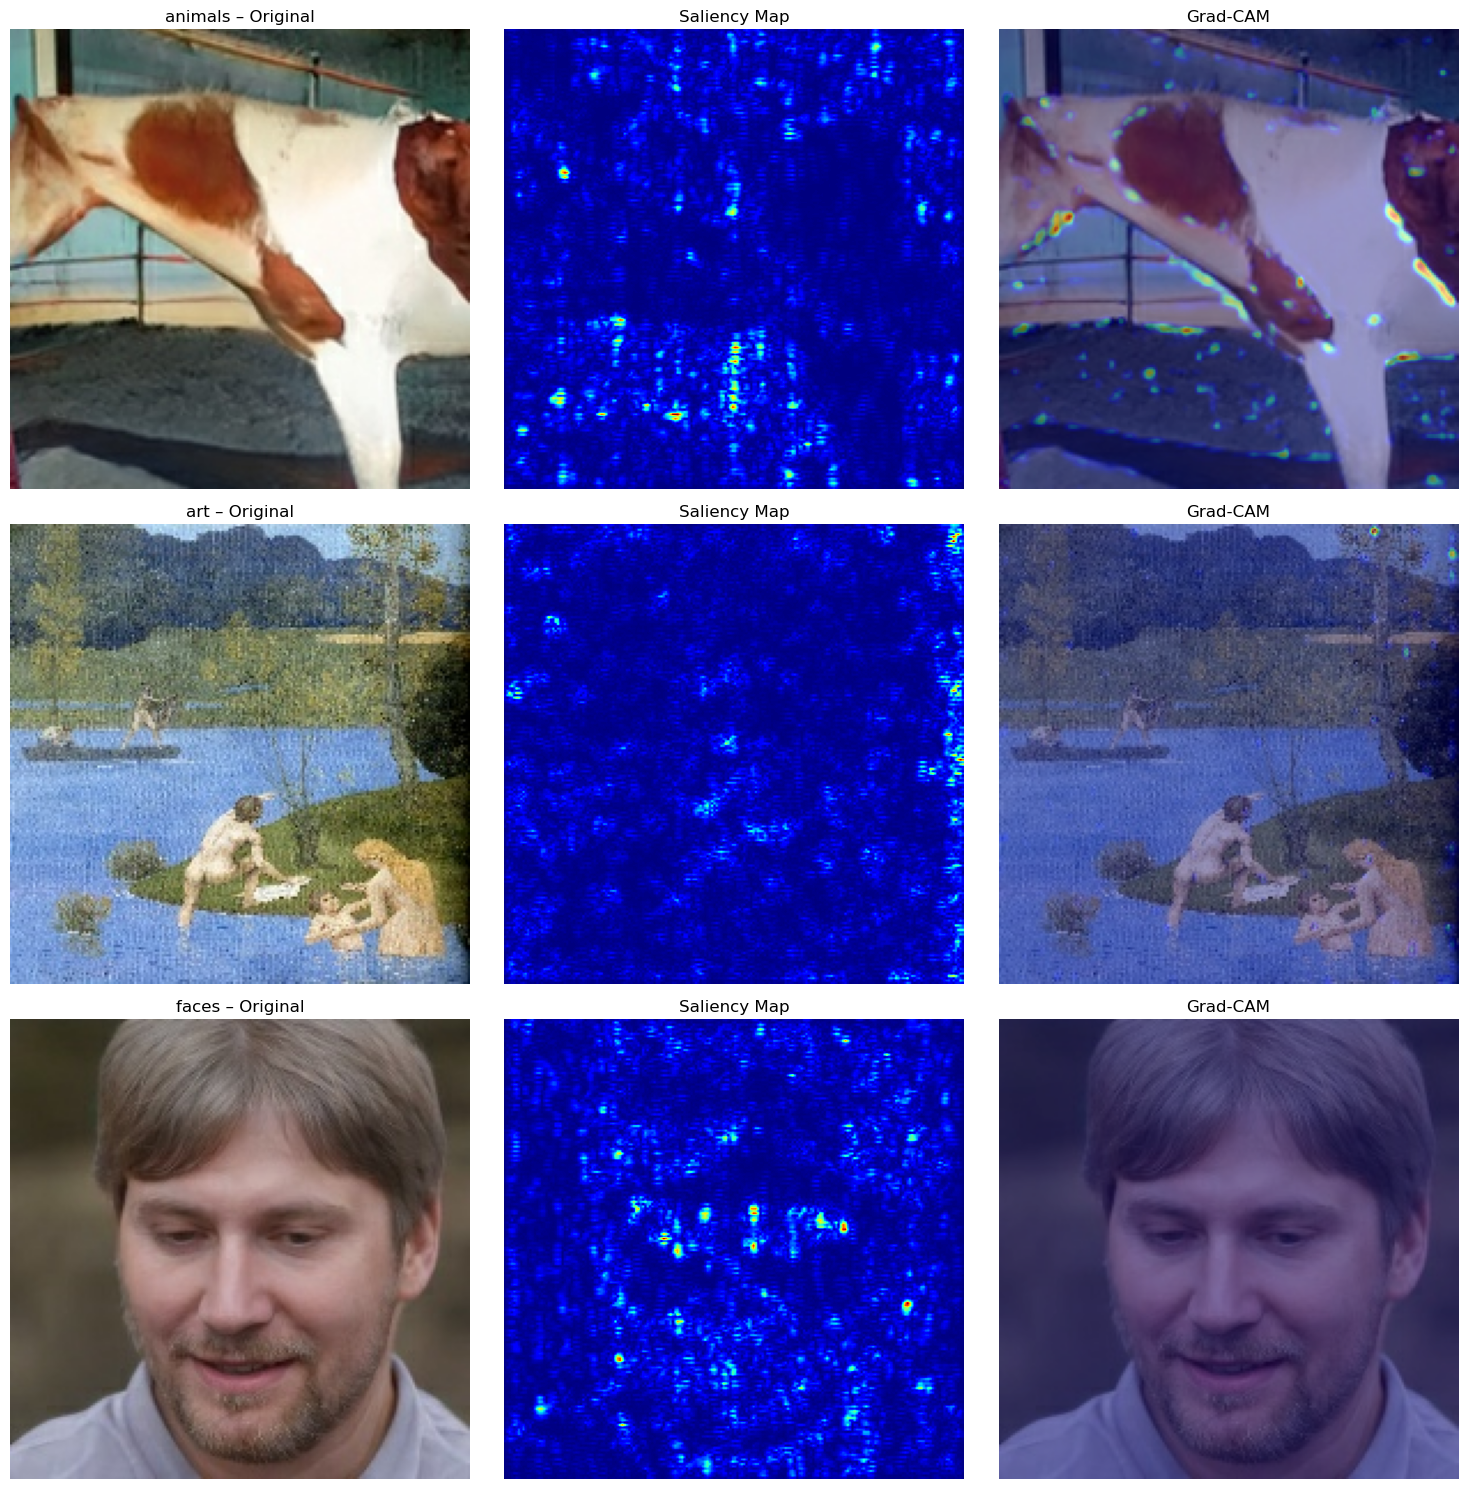

In [22]:
# we need to extract the name of the last layer from the model
last_conv_layer_name = None
for layer in model.layers:
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv_layer_name = layer.name

print(f"Last convolutional layer name: {last_conv_layer_name}")

plot_saliency_and_gradcam_per_class(model,test_dataset,class_names, last_conv_layer_name)

#### Confusion matrix

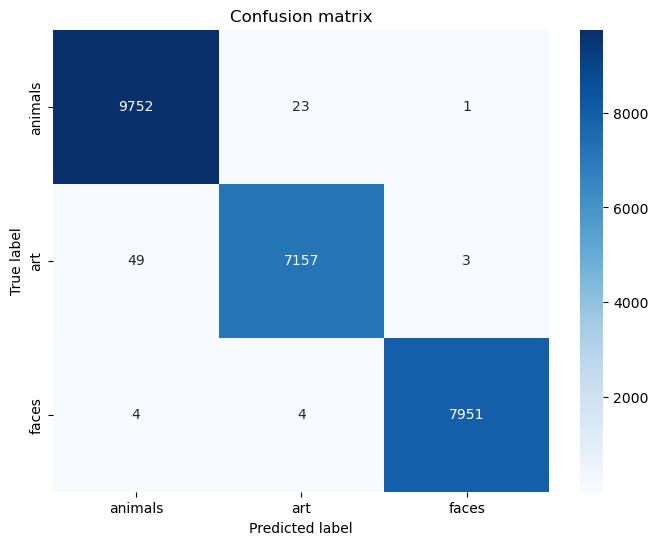

Classification report:
              precision    recall  f1-score   support

     animals     0.9946    0.9975    0.9961      9776
         art     0.9962    0.9928    0.9945      7209
       faces     0.9995    0.9990    0.9992      7959

    accuracy                         0.9966     24944
   macro avg     0.9968    0.9964    0.9966     24944
weighted avg     0.9966    0.9966    0.9966     24944



In [28]:
y_pred, y_true = get_predictions_and_labels(test_dataset, model)
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion matrix')
plt.show()

# classification report
print("Classification report:")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

### Performance analysis

Our CNN correctly classifies animals, art, and faces with 99.66% accuracy on nearly 25000 test images!

Each class has precision and recall above 0.99 (animals 0.9946/0.9975, art 0.9962/0.9928, faces 0.9995/0.9990), so only about 24 animals, 52 art pieces, and 8 faces were predicted as the wrong label

The training curves show both train and validation accuracy hitting  around 1 by a few epochs, with loss dropping near zero

Saliency maps enhances on animal outlines, paint textures in art, and key facial features and Grad-CAM heatmaps confirm the model focuses on the right spots (fur edges, brushstrokes, eyes and mouth)